# ОЧИСТКА ДАННЫХ


## Этап 1. Загрузка данных и первичный обзор

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
path_to_data = "enhanced_anxiety_dataset.csv"

# Загрузка данных
!gdown --id 1e-3Yfw8QZmu2d0fYofytIO6LoNDI6zzy
df = pd.read_csv('enhanced_anxiety_dataset.csv')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1e-3Yfw8QZmu2d0fYofytIO6LoNDI6zzy
To: /content/enhanced_anxiety_dataset.csv
100% 742k/742k [00:00<00:00, 75.5MB/s]


## Этап 2. Обзор и предобработка: проверка пропусков и обработка дубликатов

In [2]:
print("="*50)
print("СТАТИСТИКА ДО ОЧИСТКИ")
print("="*50)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Количество полных дубликатов: {df.duplicated().sum()}")
print("\nКоличество пропусков по столбцам:")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Пропусков нет.")

# Визуализация пропусков (если они есть)
if df.isnull().sum().sum() > 0:
    msno.matrix(df.sample(500))
    plt.show()
else:
    print("Датасет идеален, визуализация пропусков не требуется.")

# --- Обработка дубликатов ---
initial_shape = df.shape
df = df.drop_duplicates()
print(f"\nУдалено дубликатов: {initial_shape[0] - df.shape[0]}")

print("\n" + "="*50)
print("СТАТИСТИКА ПОСЛЕ ОЧИСТКИ")
print("="*50)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Количество дубликатов: {df.duplicated().sum()}")
print(f"Количество пропусков: {df.isnull().sum().sum()}")

СТАТИСТИКА ДО ОЧИСТКИ
Размер датасета: 11000 строк, 19 столбцов
Количество полных дубликатов: 0

Количество пропусков по столбцам:
Пропусков нет.
Датасет идеален, визуализация пропусков не требуется.

Удалено дубликатов: 0

СТАТИСТИКА ПОСЛЕ ОЧИСТКИ
Размер датасета: 11000 строк, 19 столбцов
Количество дубликатов: 0
Количество пропусков: 0


## Этап 3. Преобразование данных: форматы, переименование и Feature Engineering

In [3]:
# 1. Удаление нерелевантных столбцов (в данном датасете все несут смысловую нагрузку)
cols_to_drop = []
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

# 2. Переименование столбцов в snake_case (английский язык)
rename_mapping = {
    'Age': 'age',
    'Gender': 'gender',
    'Occupation': 'occupation',
    'Sleep Hours': 'sleep_hours',
    'Physical Activity (hrs/week)': 'physical_activity_hrs',
    'Caffeine Intake (mg/day)': 'caffeine_intake_mg',
    'Alcohol Consumption (drinks/week)': 'alcohol_consumption',
    'Smoking': 'smoking',
    'Family History of Anxiety': 'family_history_anxiety',
    'Stress Level (1-10)': 'stress_level',
    'Heart Rate (bpm)': 'heart_rate_bpm',
    'Breathing Rate (breaths/min)': 'breathing_rate',
    'Sweating Level (1-5)': 'sweating_level',
    'Dizziness': 'dizziness',
    'Medication': 'medication',
    'Therapy Sessions (per month)': 'therapy_sessions',
    'Recent Major Life Event': 'recent_major_life_event',
    'Diet Quality (1-10)': 'diet_quality',
    'Anxiety Level (1-10)': 'anxiety_level'
}
df = df.rename(columns=rename_mapping)

# 3. Приведение типов данных
categorical_cols = [
    'gender', 'occupation', 'smoking', 'family_history_anxiety',
    'dizziness', 'medication', 'recent_major_life_event'
]
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).astype('category')

numeric_cols = [
    'age', 'sleep_hours', 'physical_activity_hrs', 'caffeine_intake_mg',
    'alcohol_consumption', 'stress_level', 'heart_rate_bpm',
    'breathing_rate', 'sweating_level', 'therapy_sessions',
    'diet_quality', 'anxiety_level'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Создание новых признаков (Feature Engineering)
# Биннинг возраста для удобства сравнения групп
bins = [0, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '50+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True).astype('category')

# 5. Создание фиктивных переменных (Dummy Variables)
# Drop first=True предотвращает мультиколлинеарность (dummy trap).
df_smoking_dummies = pd.get_dummies(df['smoking'], prefix='smoking', drop_first=True, dtype=int)
df_dizziness_dummies = pd.get_dummies(df['dizziness'], prefix='dizziness', drop_first=True, dtype=int)

df = pd.concat([df, df_smoking_dummies, df_dizziness_dummies], axis=1)

# 6. Сохранение чистого датасета
def save_to_csv(output_filename):
  df.to_csv(output_filename, index=False, encoding='utf-8-sig')
  print(f" Датасет успешно преобразован и сохранен в файл: {output_filename}")
  print(f"Итоговое количество строк: {df.shape[0]}, столбцов: {df.shape[1]}")

save_to_csv("clean_data.csv")


 Датасет успешно преобразован и сохранен в файл: clean_data.csv
Итоговое количество строк: 11000, столбцов: 22


### 3.1 Русификация


In [4]:
df = pd.read_csv('clean_data.csv')

columns_mapping = {
    'age': 'возраст',
    'gender': 'пол',
    'occupation': 'профессия',
    'sleep_hours': 'часы_сна',
    'physical_activity_hrs': 'физическая_активность_часы',
    'caffeine_intake_mg': 'потребление_кофеина_мг',
    'alcohol_consumption': 'потребление_алкоголя',
    'smoking': 'курение',
    'family_history_anxiety': 'тревожность_в_семье',
    'stress_level': 'уровень_стресса(1-10)',
    'heart_rate_bpm': 'пульс_уд_мин',
    'breathing_rate': 'частота_дыхания',
    'sweating_level': 'уровень_потооделения',
    'dizziness': 'головокружение',
    'medication': 'прием_медикаментов',
    'therapy_sessions': 'сеансы_терапии',
    'recent_major_life_event': 'недавние_важные_события',
    'diet_quality': 'качество_питания',
    'anxiety_level': 'уровень_тревожности',
    'age_group': 'возрастная_группа',
    'smoking_Yes': 'курение_Да',
    'dizziness_Yes': 'головокружение_Да'
}

df = df.rename(columns=columns_mapping)

translation = {
    'Artist': 'Художник',
    'Nurse': 'Медсестра',
    'Other': 'Другие',
    'Scientist': 'Учёный',
    'Lawyer': 'Юрист',
    'Teacher': 'Учитель',
    'Doctor': 'Врач',
    'Musician': 'Музыкант',
    'Engineer': 'Инженер',
    'Student': 'Студент',
    'Chef': 'Шеф-повар',
    'Freelancer': 'Фрилансер',
    'Athlete': 'Спортсмен'
}

Gen = {
    'Male': 'Мужчина',
    'Female': 'Женщина',
    'Other': 'Неизвестно',
}

Y_N = {
    'Yes': 'Да',
    'No': 'Нет',
}

df['профессия'] = df['профессия'].map(translation).fillna(df['профессия'])
df['пол'] = df['пол'].map(Gen).fillna(df['пол'])
cat_cols = ['курение', 'тревожность_в_семье', 'головокружение',
'прием_медикаментов', 'недавние_важные_события']
for i, col in enumerate(cat_cols):
  df[col] = df[col].map(Y_N).fillna(df[col])

#добавляем столбец с уровнем стресса 1-3(низкий, средний высокий) на основе целевого признака
df['уровень_стресса(1-3)'] = pd.cut(
  df['уровень_стресса(1-10)'],
  bins=[0, 3, 6, 10],
  labels=[1, 2, 3]
).astype(int)

save_to_csv("clean_data_translated.csv")


 Датасет успешно преобразован и сохранен в файл: clean_data_translated.csv
Итоговое количество строк: 11000, столбцов: 23


Количественные и категориальные признаки

In [5]:
target_col = 'уровень_стресса(1-10)'
quant_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(target_col).tolist()

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Список признаков для сравнения")
print(f"Количественные ({len(quant_cols)}): {quant_cols}")
print(f"Категориальные ({len(cat_cols)}): {cat_cols}\n")

Список признаков для сравнения
Количественные (14): ['возраст', 'часы_сна', 'физическая_активность_часы', 'потребление_кофеина_мг', 'потребление_алкоголя', 'пульс_уд_мин', 'частота_дыхания', 'уровень_потооделения', 'сеансы_терапии', 'качество_питания', 'уровень_тревожности', 'курение_Да', 'головокружение_Да', 'уровень_стресса(1-3)']
Категориальные (8): ['пол', 'профессия', 'курение', 'тревожность_в_семье', 'головокружение', 'прием_медикаментов', 'недавние_важные_события', 'возрастная_группа']



## Промежуточные выводы по обзору и предобработке

**Итоги этапа предобработки:**
1. **Качество данных:** Исходный датасет (11 000 строк) не содержал пропущенных значений и полных дубликатов, что свидетельствует о высоком качестве сбора данных. Удаление строк не потребовалось.
2. **Формат и кодирование:** Названия столбцов приведены к единому стандарту `snake_case`. Категориальные признаки переведены в тип `category` для экономии памяти и корректной работы алгоритмов, числовые — к `float64` и `int64`.
3. **Feature Engineering (Создание признаков):**
   - Создан новый интервальный признак `возрастная_группа` для удобства A/B тестирования и сравнения когорт.
   - Созданы **фиктивные переменные** (`курение_Да`, `головокружение_Да`) для корректного использования бинарных категориальных признаков в регрессионных моделях (с применением `drop_first=True` для избежания мультиколлинеарности).

**Признаки, остающиеся для дальнейшего анализа (всего 22 столбца):**

**Целевой признак (Target):**
* `уровень_тревожности` (от 1 до 10) — *количественный / порядковый*. Именно его мы будем прогнозировать и анализировать.

**Количественные (числовые) признаки (14 шт.):**
* `возраст`
* `часы_сна`
* `физическая_активность_часы`
* `потребление_кофеина_мг`
* `потребление_алкоголя`
* `уровень_стресса` (от 1 до 10)
* `пульс_уд_мин`
* `частота_дыхания`
* `уровень_потоотделения` (от 1 до 5)
* `сеансы_терапии`
* `качество_питания` (от 1 до 10)
* `курение_Да`, `головокружение_Да` (бинарные переменные, 0/1)

**Категориальные (качественные) признаки (8 шт.):**
* `пол`
* `профессия`
* `курение`
* `тревожность_в_семье`
* `головокружение`
* `прием_медикаментов`
* `недавние_важные_события`
* `возрастная_группа`



##

# ОПИСАТЕЛЬНАЯ СТАТИСТИКА


## Расчёт основных числовых показателей

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
#Создание таблицы для основных числовых показателей
stat_df = pd.DataFrame(index=numeric_cols)
#Расчёты
stat_df['Среднее_значение'] = df[numeric_cols].mean()
stat_df['Медиана'] = df[numeric_cols].median()
stat_df['Мода'] = df[numeric_cols].mode().iloc[0]
stat_df['Стандартное_отклонение'] = df[numeric_cols].std()
stat_df['25%'] = df[numeric_cols].quantile(0.25)
stat_df['75%'] = df[numeric_cols].quantile(0.75)
stat_df.head(12)

,Среднее_значение,Медиана,Мода,Стандартное_отклонение,25%,75%
возраст,40.241727,40.0,30.0,13.236140,29.0,51.0
часы_сна,6.650691,6.7,6.7,1.227509,5.9,7.5
физическая_активность_часы,2.942136,2.8,1.9,1.827825,1.5,4.2
потребление_кофеина_мг,286.090000,273.0,294.0,144.813157,172.0,382.0
потребление_алкоголя,9.701636,10.0,9.0,5.689713,5.0,15.0
уровень_стресса(1-10),5.856364,6.0,10.0,2.927202,3.0,8.0
пульс_уд_мин,90.916000,92.0,112.0,17.325721,76.0,106.0
частота_дыхания,20.957545,21.0,26.0,5.160107,17.0,25.0
уровень_потооделения,3.080636,3.0,5.0,1.398877,2.0,4.0
сеансы_терапии,2.427818,2.0,1.0,2.183106,1.0,4.0


## Использование гистограмм для просмотра данных с большим разбросом или определённой тенденцией


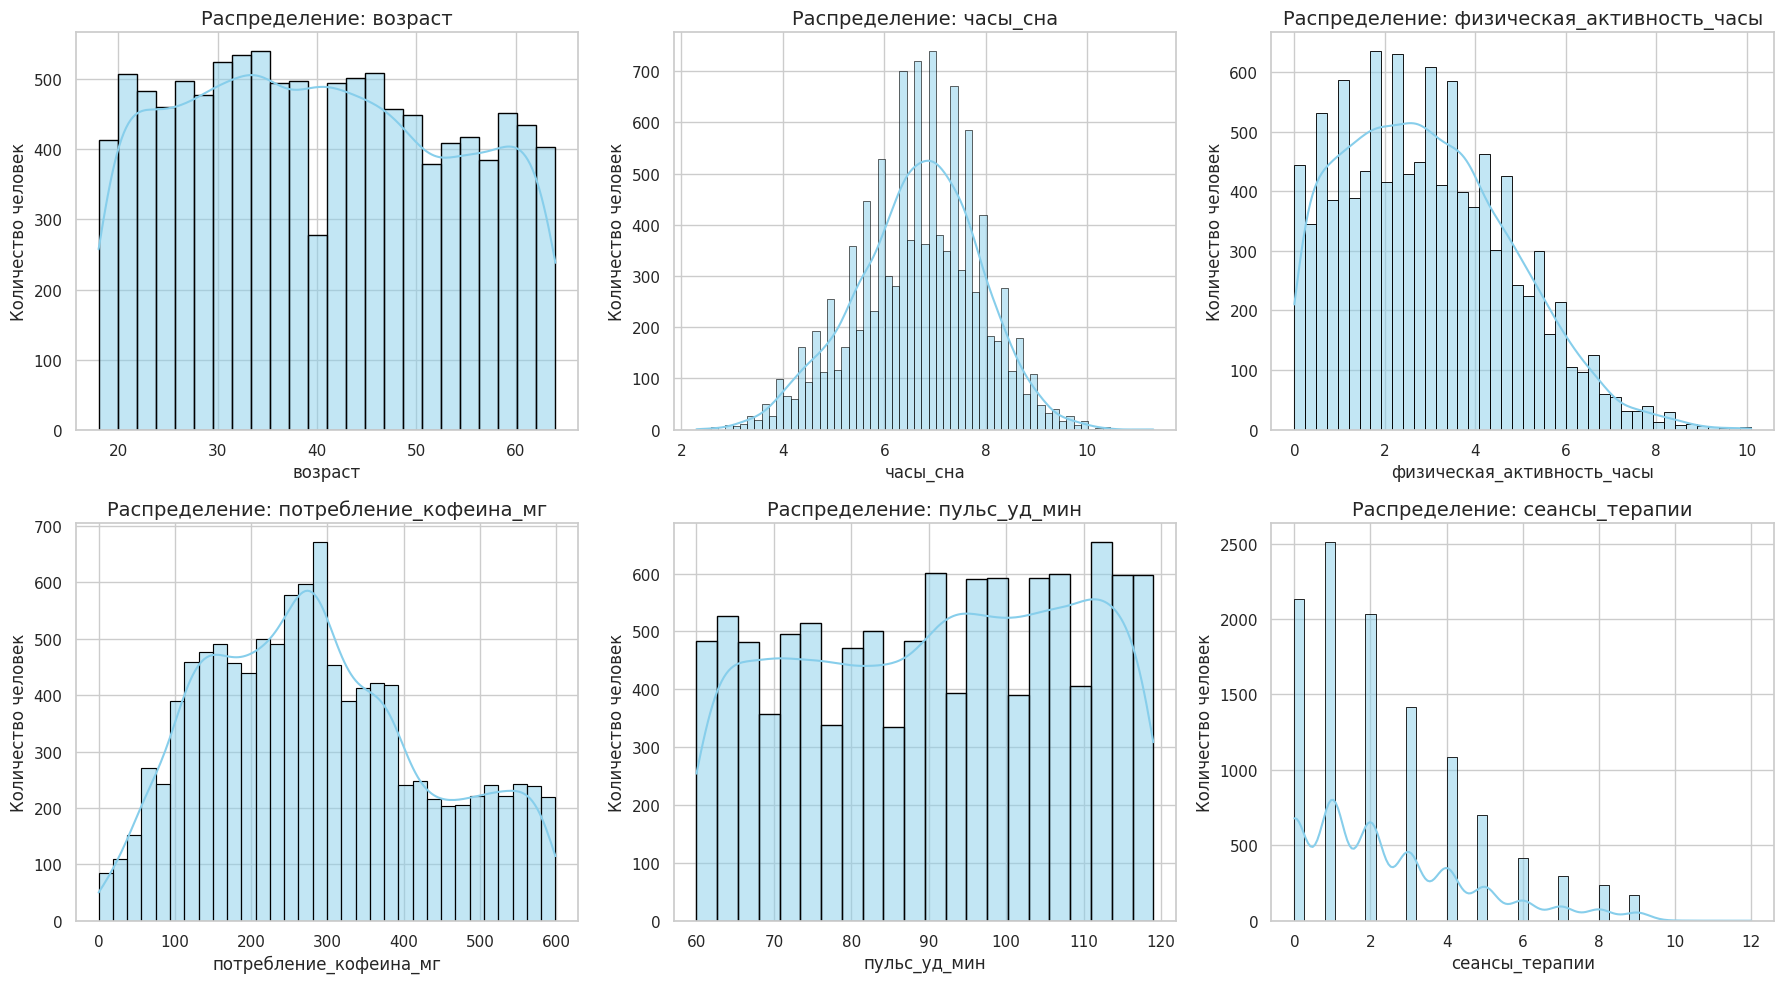

In [7]:
# Построение гистограмм
num_cols = ['возраст', 'часы_сна', 'физическая_активность_часы',
'потребление_кофеина_мг', 'пульс_уд_мин', 'сеансы_терапии']
n_cols = len(num_cols)
nrows = (n_cols + 2) // 3
fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(18, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Распределение: {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество человек')

plt.tight_layout()
plt.show()

## Промежуточные итоги 1
Из данных графиков можно сделать промежуточные выводы:


*   Age (возраст) – график идёт в большей степени сбалансированно, что может говорить о том, что оно было намеренно сбалансированно. Но также наблюдается провал в районе 40 лет (возможно артефакт выборки).
*   Sleep_hours (часы сна) – соответствует нормальному распределению. Люди чаще спят не слишком много и не слишком мало времени, так как оба варианта приводят к плохому состоянию.
*   Physical_activity_hrs (часы физической активности) – распределение скошенно вправо, что обусловленно тем, что многие люди не могут или не хотят уделят слишком много времени тренировкам
*   Caffeine_intake_mg (получаемый кофеин в мг.) – распределение потребления кофеина имеет пик около 300 мг и диапазон примерно 100–600 мг. Форма близка к нормальной с небольшим правым хвостом (некоторые потребляют 500–600 мг).
*   Heart_rate_bpm (сердцебиение в минуту) – распределение пульса мультимодальное с несколькими пиками (около 65, 75, 90, 100 и 110–115 уд/мин).
*   Therapy_sessions (сеансы у терапевта) – распределение скошенно вправо, к тому же спад резкий.







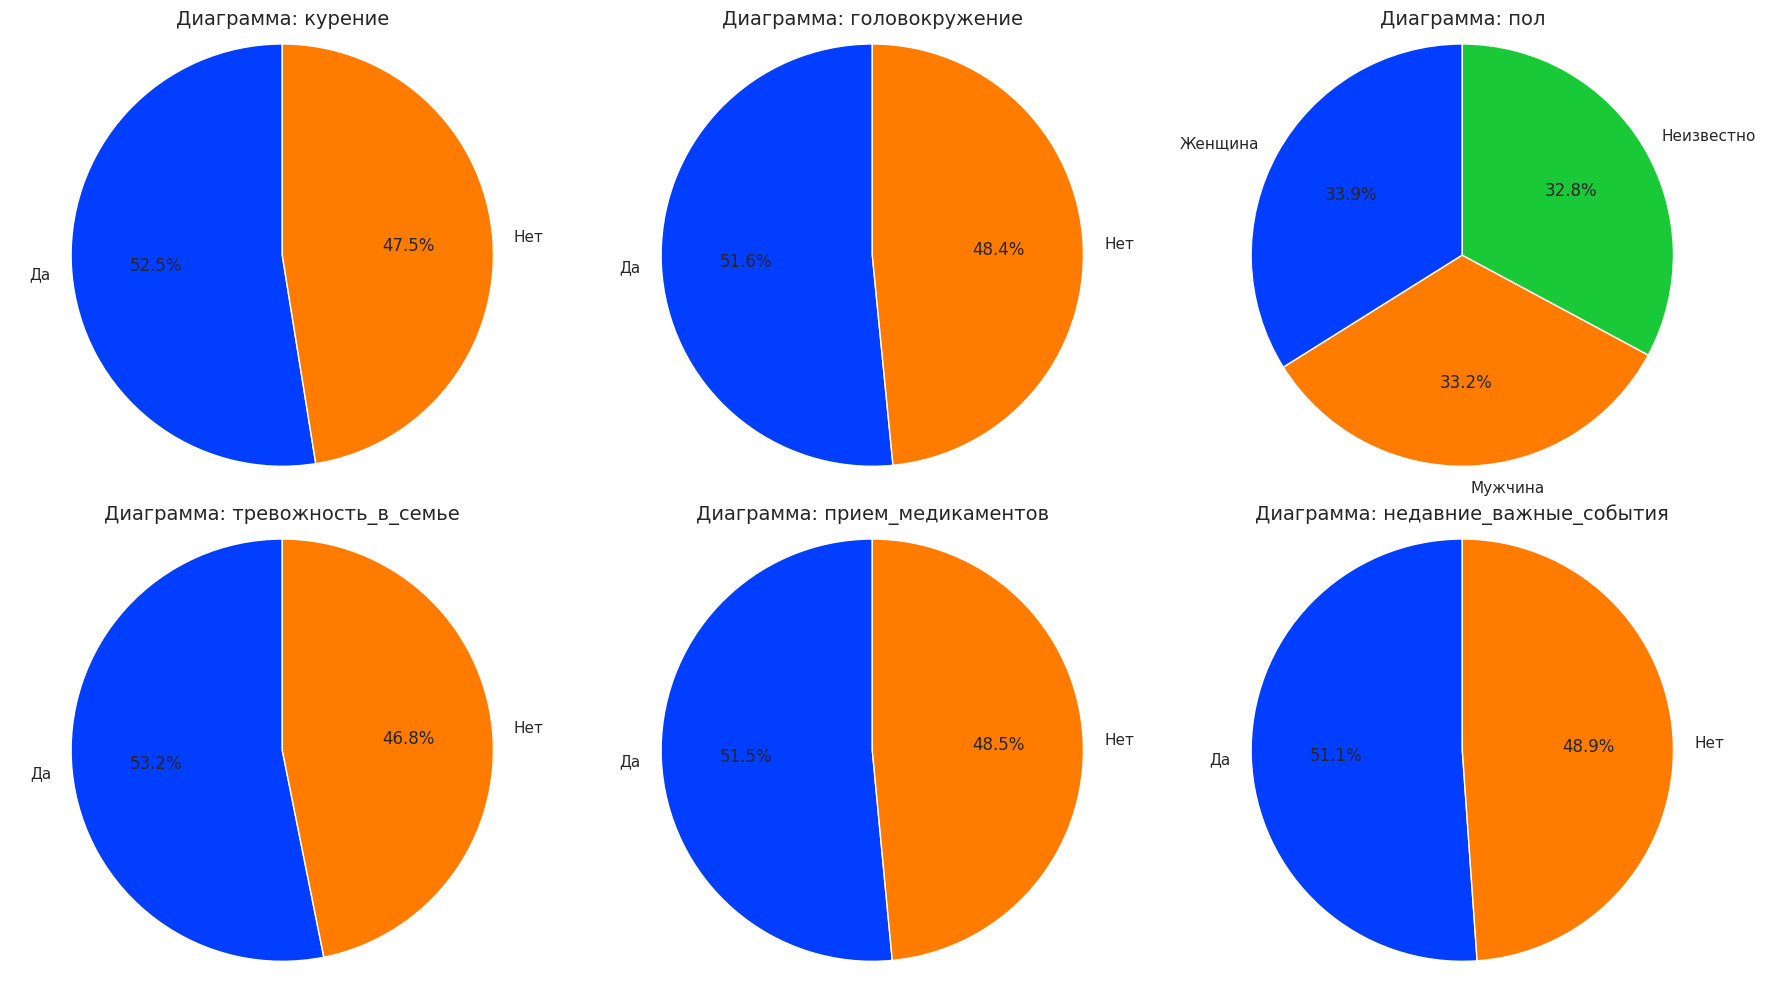

In [8]:
t = ['курение', 'головокружение', 'пол', 'тревожность_в_семье', 'прием_медикаментов', 'недавние_важные_события']
circle = df[t]
colors = sns.color_palette('bright')

c_cols = len(circle.columns)
rows = (c_cols + 2) // 3
fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(18, 5*rows))
axes = axes.flatten()

for i, col in enumerate(circle.columns):
    counts = circle[col].dropna().value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[i].set_title(f'Диаграмма: {col}', fontsize=14)
    axes[i].axis('equal')

plt.tight_layout()
plt.show()


Во всех диаграммах распределение почти равномерное. Возможно датасет был отредактирован, чтобы выборка была репрезентативной для всех групп населения.

Text(0.5, 1.0, 'Профессии')

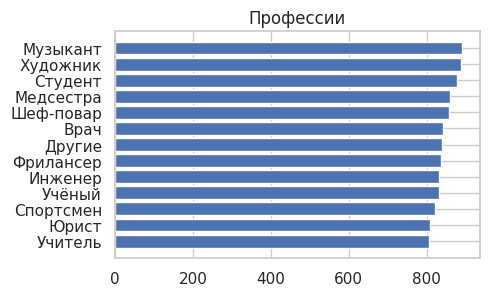

In [9]:
occup = df['профессия'].value_counts().sort_values(ascending=True)
plt.figure(figsize=(16, 10))
plt.subplot(3, 3, 1)
plt.barh(occup.index, occup.values)
plt.title('Профессии')


*   Диаграмма профессии почти равномерная – показывает, что рассматривались люди одной профессии в количестве от 800 человек



Использование boxplot'а для визуализации распределения числовых данных разных переменных и Q-Q графика для определения нормальности

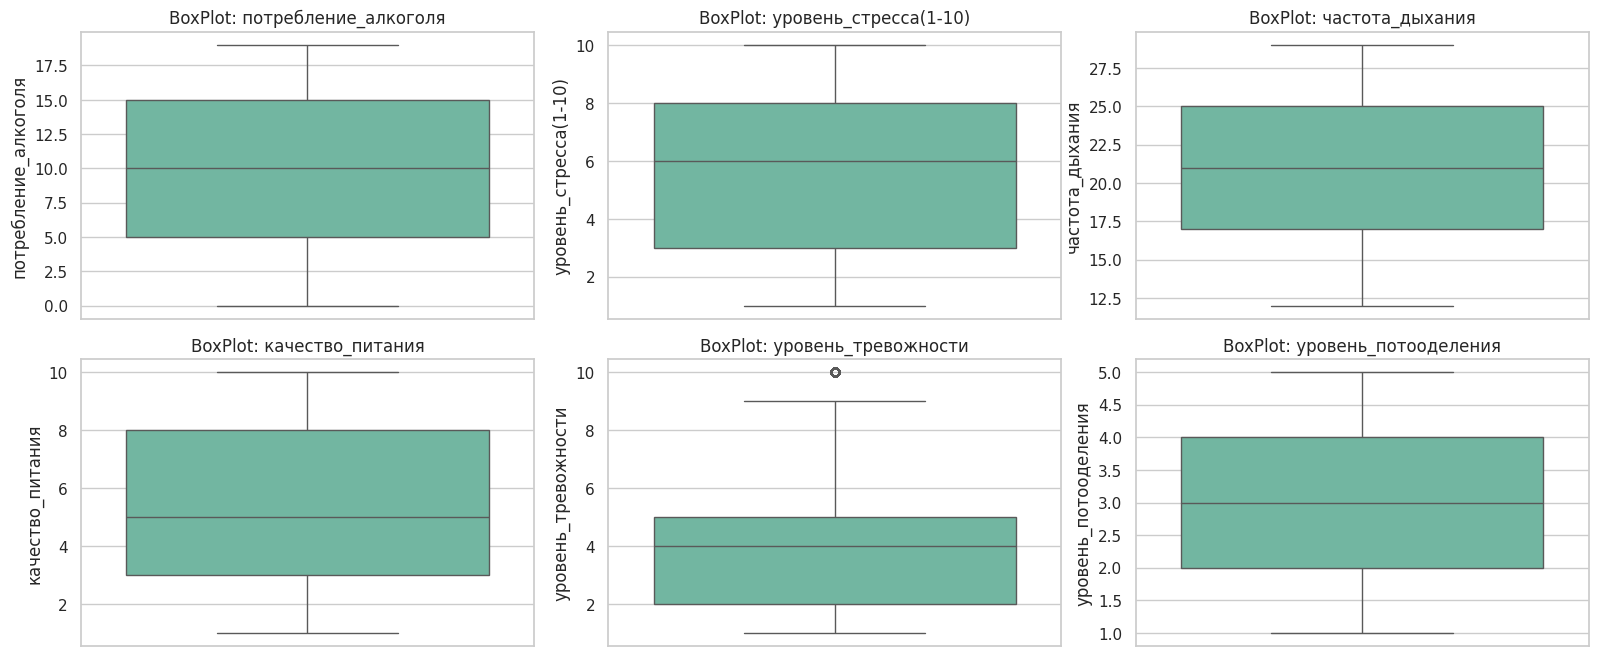

In [10]:
# BoxPlots
key_metrics = ['потребление_алкоголя', 'уровень_стресса(1-10)', 'частота_дыхания', 'качество_питания', 'уровень_тревожности', 'уровень_потооделения']
plt.figure(figsize=(16, 10))
for i, col in enumerate(key_metrics, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df[col], palette="Set2", legend=False)
    plt.title(f'BoxPlot: {col}', fontsize=12)
    plt.ylabel(col)
plt.tight_layout()
plt.show()

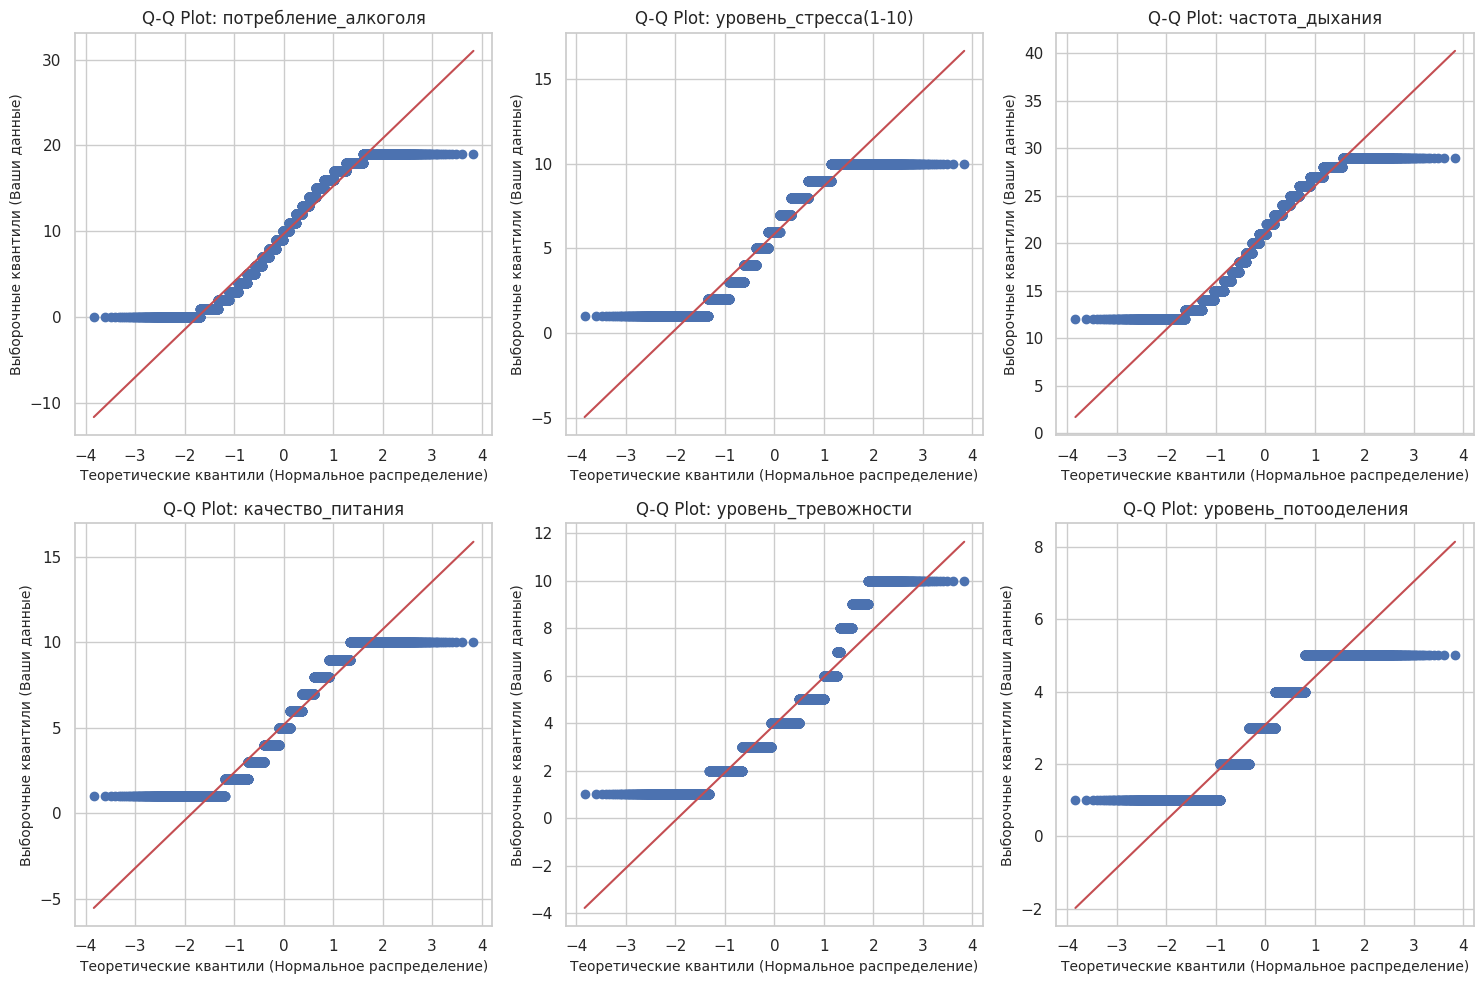

In [11]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(key_metrics, 1):
    plt.subplot(2, 3, i)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot: {col}', fontsize=12)
    plt.xlabel('Теоретические квантили (Нормальное распределение)', fontsize=10)
    plt.ylabel('Выборочные квантили (Ваши данные)', fontsize=10)

plt.tight_layout()
plt.show()

## Промежуточные итоги 2
По этим графикам видно:


1. Потребление алкоголя (медиана = 10).
Средний уровень потребления алкоголя составляет около 10 единиц в неделю,
разброс значений от 0 до ~19.
Распределение близкое к равномерному с небольшим утолщением в середине
2. Уровень стресса (медиана = 6).
Средний уровень стресса - 6 баллов из 10,
диапазон от 1 до 10,
высокий средний уровень стресса в выборке. Часть людей испытывают стресс выше среднего
распределение почти прямоугольное (равномерное)
3. Частота дыхания (медиана = 21).
Средняя частота дыхания около 21 вдоха в минуту,
разброс от 12 до 29,
распределение симметричное.
Показатели в пределах физиологической нормы (12-20 вдохов/мин — норма, но 21 тоже допустимо)
4. Качество питания (медиана = 5).
Среднее качество питания - 5 баллов из 10 (средний уровень),
диапазон от 1 до 10,
равномерное распределение.
Среднее качество питания — неудовлетворительное. есть как люди с очень плохим питанием (1-3), так и с отличным (8-10)
5. Уровень тревожности (медиана = 4).
Средний уровень тревожности - 4 балла из 10,
есть выбросы (отмечены кружками) - люди с аномально высоким уровнем тревожности,
распределение с небольшим смещением.
У большинства умеренная тревожность, но присутствует группа людей с критически высоким уровнем тревоги
6. Уровень потооделения (медиана = 3).
у опрашиваемых потоотделение в пределах нормы

Среди представленных отсутствуют графики с нормальным распределением

## Взаимосвязь категориальнх и количественных признаков

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
target_col = 'уровень_стресса(1-3)'
df = pd.read_csv('clean_data_translated.csv')
df_clean = df.copy()

Исключаем вторую шкалу стресса и бинарные дубликаты категориальных признаков

In [14]:
# cols_to_drop = [
#     'курение_Да', 'головокружение_Да',
#     'smoking_Yes.1', 'dizziness_Yes.1'
# ]
# df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [15]:
print("Средние значения количественных признаков")
print(df.groupby(target_col)[quant_cols].mean().round(2))

Средние значения количественных признаков
                      возраст  часы_сна  физическая_активность_часы  \
уровень_стресса(1-3)                                                  
1                       40.86      6.84                        3.13   
2                       40.62      6.87                        3.10   
3                       39.65      6.41                        2.74   

                      потребление_кофеина_мг  потребление_алкоголя  \
уровень_стресса(1-3)                                                 
1                                     270.92                  9.48   
2                                     268.86                  9.35   
3                                     305.21                 10.04   

                      пульс_уд_мин  частота_дыхания  уровень_потооделения  \
уровень_стресса(1-3)                                                        
1                            89.26            20.66                  2.94   
2                   

In [16]:
print("\n Процентное распределение категориальных признаков")
for col in cat_cols:
    print()
    print(pd.crosstab(df_clean[target_col], df_clean[col], normalize='index') * 100)


 Процентное распределение категориальных признаков

пол                     Женщина    Мужчина  Неизвестно
уровень_стресса(1-3)                                  
1                     34.580075  32.675961   32.743965
2                     34.008635  34.207904   31.783461
3                     33.458796  33.003170   33.538035

профессия                 Врач    Другие   Инженер  Медсестра  Музыкант  \
уровень_стресса(1-3)                                                      
1                     7.684461  7.650459  7.582455   7.582455  7.854471   
2                     6.808369  7.572235  7.240120   8.103620  8.070409   
3                     8.141838  7.666403  7.765452   7.805071  8.280507   

профессия             Спортсмен   Студент   Учитель    Учёный  Фрилансер  \
уровень_стресса(1-3)                                                       
1                      7.378443  7.990479  7.548453  7.956477   7.752465   
2                      7.472600  7.638658  7.273331  8.003985   7.8

## Количественные признаки

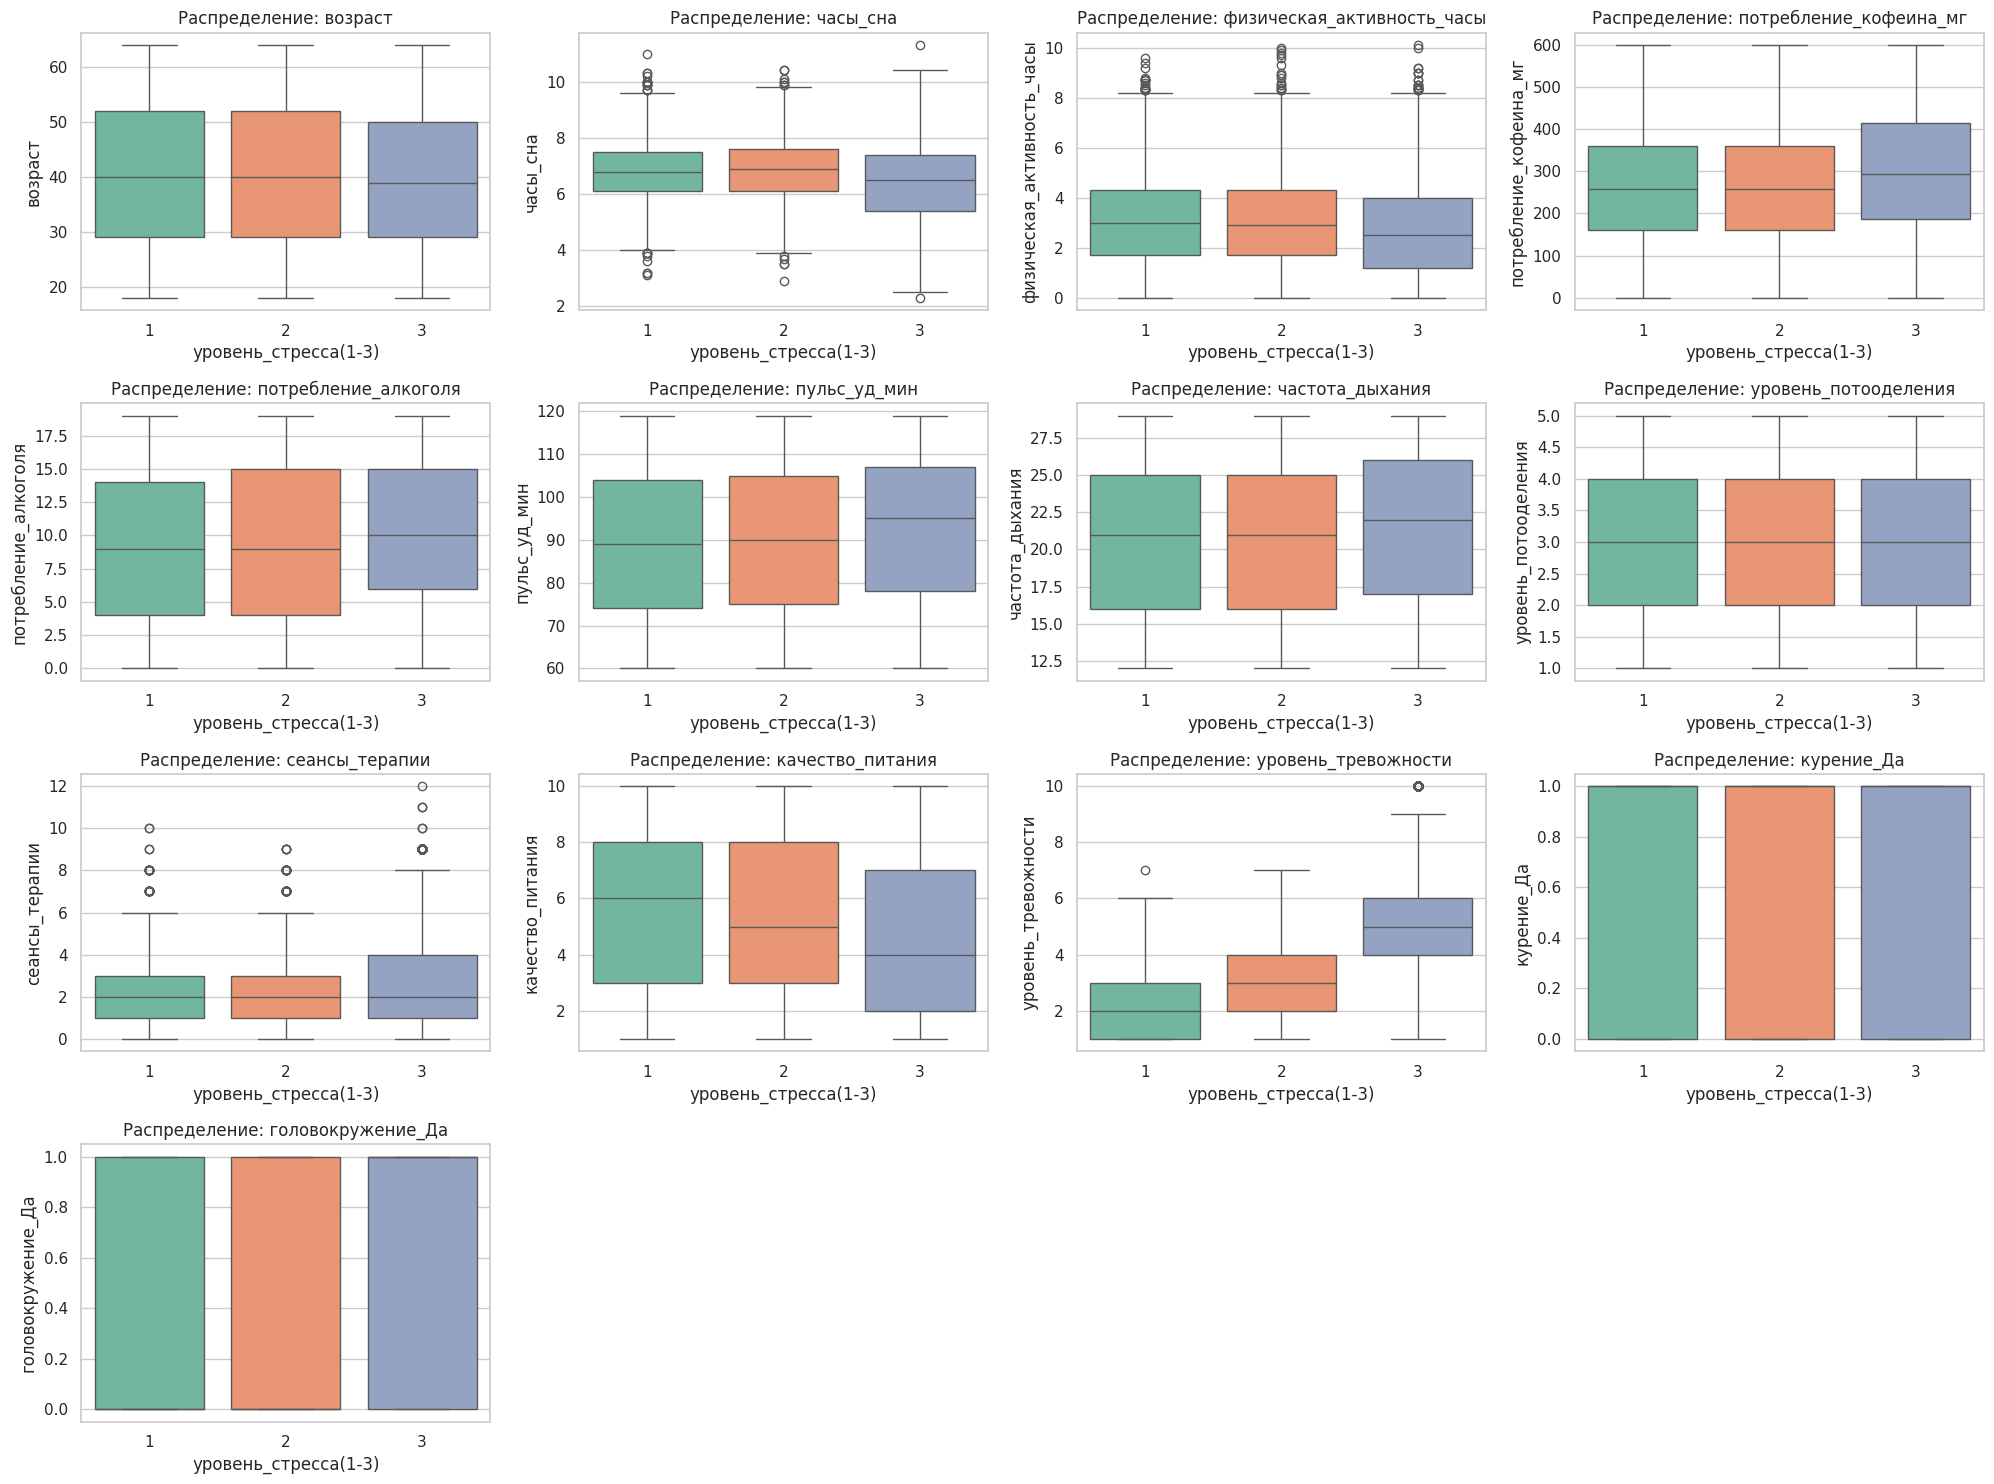

In [17]:
# Исключаем целевую переменную из списка количественных признаков
quant_cols = [col for col in quant_cols if col != target_col]
n_quant = len(quant_cols)
fig, axes = plt.subplots(nrows=(n_quant // 4) + 1, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(quant_cols):
    sns.boxplot(x=target_col, y=col, data=df_clean, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Распределение: {col}')

for j in range(i + 1, len(axes)): # Скрываем пустые подграфики
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Количественные признаки ВЫВОД
 Самый сильный маркер — уровень_тревожности: Его среднее значение растет почти линейно и очень значительно: с 2.23 (стресс 1) до 3.40 (стресс 2) и до 5.69 (стресс 3).

пульс_уд_мин и частота_дыхания стабильно растут (пульс с 89.2 до 93.2, дыхание с 20.6 до 21.5)

уровень_потооделения также плавно увеличивается (с 2.94 до 3.25).

потребление_кофеина_мг делает резкий скачок на 3-м уровне: люди потребляют в среднем 314 мг кофеина против 270 мг при низком стрессе.

качество_питания неуклонно падает (оценка снижается с 5.54 до 4.73)

физическая_активность_часы и часы_сна заметно проседают именно на 3-м уровне стресса (сон падает с ~6.8 часов до 6.29, активность с ~3.1 до 2.64)

Обращение за помощью: сеансы_терапии резко возрастают на высоком уровне стресса (с 2.0 до 3.13 сеанса).

Возраст: Наблюдается легкое снижение среднего возраста (с 40.8 лет до 39.3 лет), что говорит о том, что более молодые люди в этой выборке склонны к чуть более высокому уровню стресса.

## Категориальные признаки

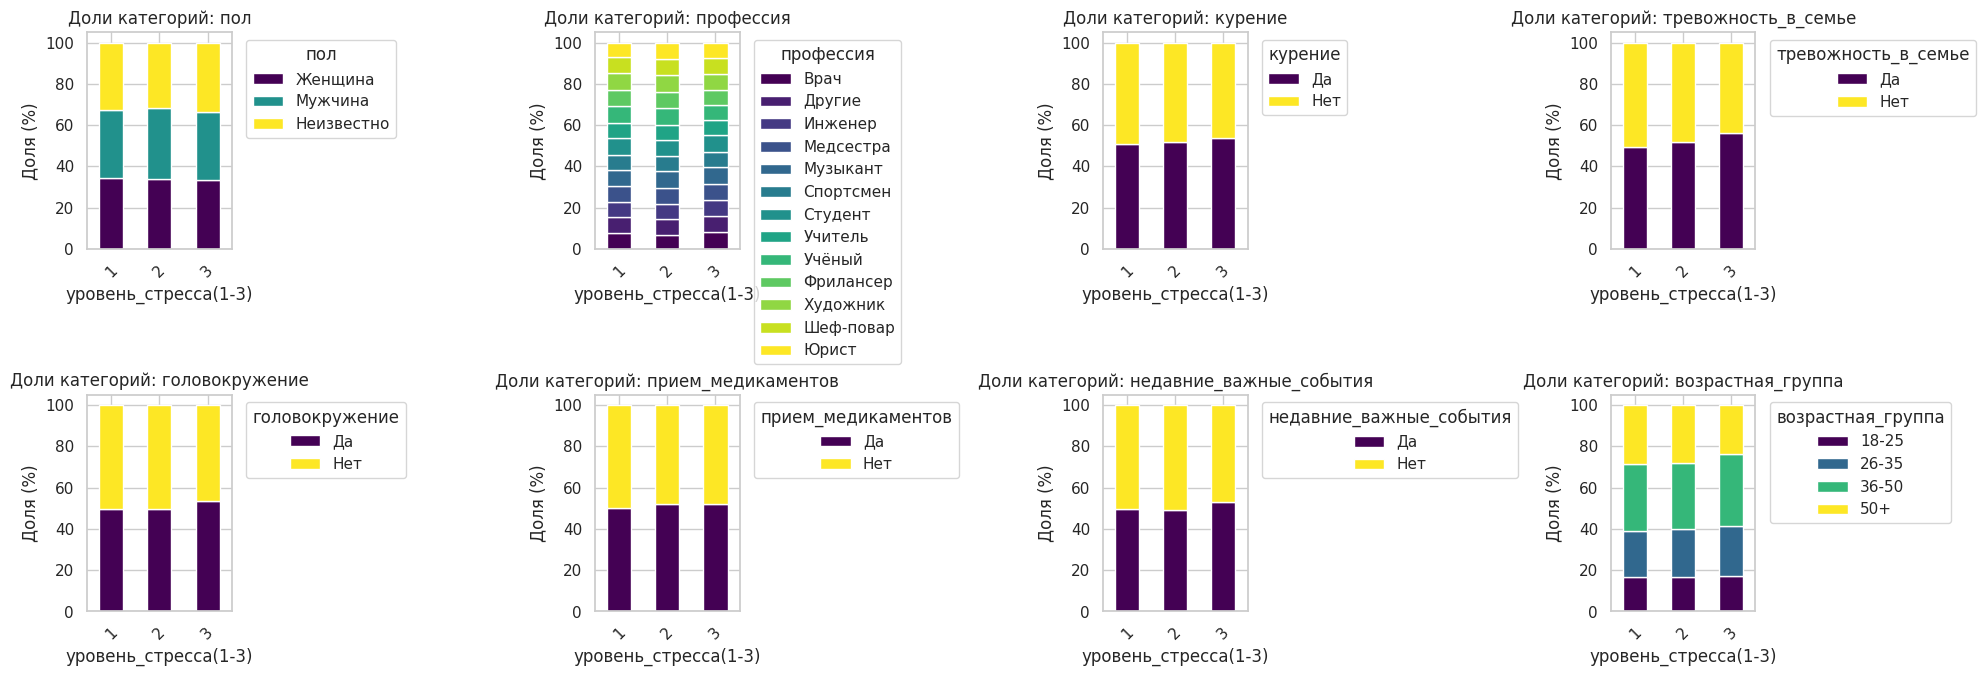

In [18]:
n_cat = len(cat_cols)
fig, axes = plt.subplots(nrows=(n_cat // 4) + 1, ncols=4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df_clean[target_col], df_clean[col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_title(f'Доли категорий: {col}')
    axes[i].set_ylabel('Доля (%)')
    axes[i].legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## Категориальные признаки ВЫВОД

Психологические симптомы и окружение (Резкий скачок на 3-м уровне):
тревожность_в_семье: Доля людей, испытывающих тревогу в семье, резко возрастает с 49.4% до 57.4% при максимальном стрессе.

головокружение: Аналогичный скачок — с 49.7% до 55.3%.

недавние_важные_события: Доля переживших важные события также подскакивает до 54.4% на 3-м уровне.

Вредные привычки и лечение (Плавный рост):

курение: Доля курящих плавно растет от 50.8% до 54.1%

прием_медикаментов: Доля принимающих лекарства также плавно увеличивается (с 49.9% до 52.8%).

Демография:
пол не оказывает никакого влияния на уровень стресса (код показал 0% для категории "Да", так как пол кодируется как Мужчина/Женщина/Неизвестно, и их распределение равномерно во всех группах стресса).


## Вывод и гипотезы

Самыми важными признаками для предсказания высокого уровня стресса (класс 3) будут уровень_тревожности, потребление_кофеина, сеансы_терапии, головокружение, тревожность в семье и часы сна.

**Уровень тревожности**

H₀ (Нулевая гипотеза): Уровень тревожности не влияет на уровень стресса. Распределение уровня тревожности одинаково во всех трех группах (стресс 1, 2, 3).

H₁ (Альтернативная гипотеза): Уровень тревожности статистически значимо влияет на уровень стресса. С ростом уровня стресса увеличивается средний уровень тревожности.

**Сеансы терапии**

H₀: Количество сеансов терапии не влияет на уровень стресса. Люди с разным уровнем стресса посещают терапевта с одинаковой частотой.

H₁: Количество сеансов терапии статистически значимо связано с уровнем стресса. Люди с высоким уровнем стресса чаще обращаются к психотерапевту.

**Часы сна**

H₀: Продолжительность сна не влияет на уровень стресса. Среднее количество часов сна одинаково во всех группах стресса.

H₁: Продолжительность сна статистически значимо связана с уровнем стресса. Люди с высоким уровнем стресса спят меньше.

**Потребление кофеина (мг)**

H₀: Потребление кофеина не связано с уровнем стресса. Среднее потребление кофеина одинаково во всех группах стресса.

H₁: Потребление кофеина статистически значимо связано с уровнем стресса. Люди с высоким уровнем стресса потребляют больше кофеина.

Такие признаки, как пол или возраст, имеют низкую предсказательную силу и могут быть удалены из модели для упрощения.

##

# РЕГРЕССИЯ

In [19]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


target = 'уровень_стресса(1-10)'

key_metrics = [
    "уровень_тревожности",
    "потребление_кофеина_мг",
    "сеансы_терапии",
    "головокружение",
    "тревожность_в_семье",
    'часы_сна'
]


def yes_no_to_bool(s):
    if s == 'Да' or s == 1:
        return 1
    else:
        return 0

df["головокружение"] = df["головокружение"].apply(yes_no_to_bool)
df["тревожность_в_семье"] = df["тревожность_в_семье"].apply(yes_no_to_bool)

## Парная линейная регрессия

In [20]:
print("="*70)
print("1. ПАРНАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ (statsmodels)")
print("="*70)

results_summary = []

for col in key_metrics:
    if col in df.columns:
        X = sm.add_constant(df[col])
        y = df[target]
        model = sm.OLS(y, X).fit()

        print(f"\n--- {col} ---")
        print(model.summary().tables[1])

        results_summary.append({
            'Фактор': col,
            'Коэффициент': model.params[col],
            'p-value': model.pvalues[col],
            'R2': model.rsquared,
            'Значимость': 'Да' if model.pvalues[col] < 0.05 else 'Нет'
        })

df_stats = pd.DataFrame(results_summary)
print("\n\n📊 Сводная таблица по парным регрессиям:")
display(df_stats)

1. ПАРНАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ (statsmodels)

--- уровень_тревожности ---
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.2368      0.044     51.177      0.000       2.151       2.322
уровень_тревожности     0.9212      0.010     94.123      0.000       0.902       0.940

--- потребление_кофеина_мг ---
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      5.1542      0.061     84.017      0.000       5.034       5.274
потребление_кофеина_мг     0.0025      0.000     12.829      0.000       0.002       0.003

--- сеансы_терапии ---
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

,Фактор,Коэффициент,p-value,R2,Значимость
0,уровень_тревожности,0.921159,0.000000e+00,0.446142,Да
1,потребление_кофеина_мг,0.002454,2.096125e-37,0.014744,Да
2,сеансы_терапии,0.280366,6.224080e-109,0.043721,Да
3,головокружение,0.268519,1.506784e-06,0.002102,Да
4,тревожность_в_семье,0.356635,1.750110e-10,0.003696,Да
5,часы_сна,-0.422837,2.185806e-78,0.031441,Да


## Множественная регрессия (sklearn)

In [21]:
print("\n" + "="*70)
print("2. МНОЖЕСТВЕННАЯ РЕГРЕССИЯ (sklearn) - прогноз")
print("="*70)

available_metrics = [col for col in key_metrics if col in df.columns]

X_multi = df[available_metrics]
y_multi = df[target]

lr_multi = LinearRegression().fit(X_multi, y_multi)
y_pred_multi = lr_multi.predict(X_multi)

print(f"R² (коэффициент детерминации): {r2_score(y_multi, y_pred_multi):.4f}")
print(f"MAE (средняя абсолютная ошибка): {mean_absolute_error(y_multi, y_pred_multi):.4f}")
print(f"RMSE (среднеквадратичная ошибка): {np.sqrt(mean_squared_error(y_multi, y_pred_multi)):.4f}")
print("\nКоэффициенты модели:")
for feature, coef in zip(available_metrics, lr_multi.coef_):
    print(f"  {feature}: {coef:+.4f}")
print(f"  Intercept: {lr_multi.intercept_:.4f}")



2. МНОЖЕСТВЕННАЯ РЕГРЕССИЯ (sklearn) - прогноз
R² (коэффициент детерминации): 0.5101
MAE (средняя абсолютная ошибка): 1.6783
RMSE (среднеквадратичная ошибка): 2.0487

Коэффициенты модели:
  уровень_тревожности: +1.2226
  потребление_кофеина_мг: -0.0023
  сеансы_терапии: -0.2270
  головокружение: -0.0350
  тревожность_в_семье: +0.0179
  часы_сна: +0.4388
  Intercept: -0.6449


## Квадратичная и экспоненциальная регрессия

In [22]:
print("\n" + "="*70)
print("3. СРАВНЕНИЕ МОДЕЛЕЙ: линейная / квадратичная / экспоненциальная")
print("="*70)

comparison = []

for col in available_metrics:
    x = df[col].values.reshape(-1, 1)
    y = df[target].values

    # Линейная
    lr = LinearRegression().fit(x, y)
    y_pred_lin = lr.predict(x)
    r2_lin = r2_score(y, y_pred_lin)

    # Квадратичная
    poly = PolynomialFeatures(degree=2, include_bias=False)
    x_poly = poly.fit_transform(x)
    lr_quad = LinearRegression().fit(x_poly, y)
    y_pred_quad = lr_quad.predict(x_poly)
    r2_quad = r2_score(y, y_pred_quad)

    # Экспоненциальная
    y_log = np.log(y)
    lr_exp = LinearRegression().fit(x, y_log)
    y_pred_exp_log = lr_exp.predict(x)
    y_pred_exp = np.exp(y_pred_exp_log)
    r2_exp = r2_score(y, y_pred_exp)

    best_model = max([('Линейная', r2_lin), ('Квадратичная', r2_quad),
                      ('Экспоненциальная', r2_exp)], key=lambda t: t[1])[0]

    comparison.append({
        'Фактор': col,
        'R² линейная': round(r2_lin, 4),
        'R² квадратичная': round(r2_quad, 4),
        'R² экспоненциальная': round(r2_exp, 4),
        'Лучшая модель': best_model
    })

df_comparison = pd.DataFrame(comparison)
display(df_comparison)


3. СРАВНЕНИЕ МОДЕЛЕЙ: линейная / квадратичная / экспоненциальная


,Фактор,R² линейная,R² квадратичная,R² экспоненциальная,Лучшая модель
0,уровень_тревожности,0.4461,0.5131,0.1179,Квадратичная
1,потребление_кофеина_мг,0.0147,0.0160,-0.0989,Квадратичная
2,сеансы_терапии,0.0437,0.0566,-0.0610,Квадратичная
3,головокружение,0.0021,0.0021,-0.1135,Линейная
4,тревожность_в_семье,0.0037,0.0037,-0.1116,Линейная
5,часы_сна,0.0314,0.0544,-0.0760,Квадратичная


## Визуализация всех моделей

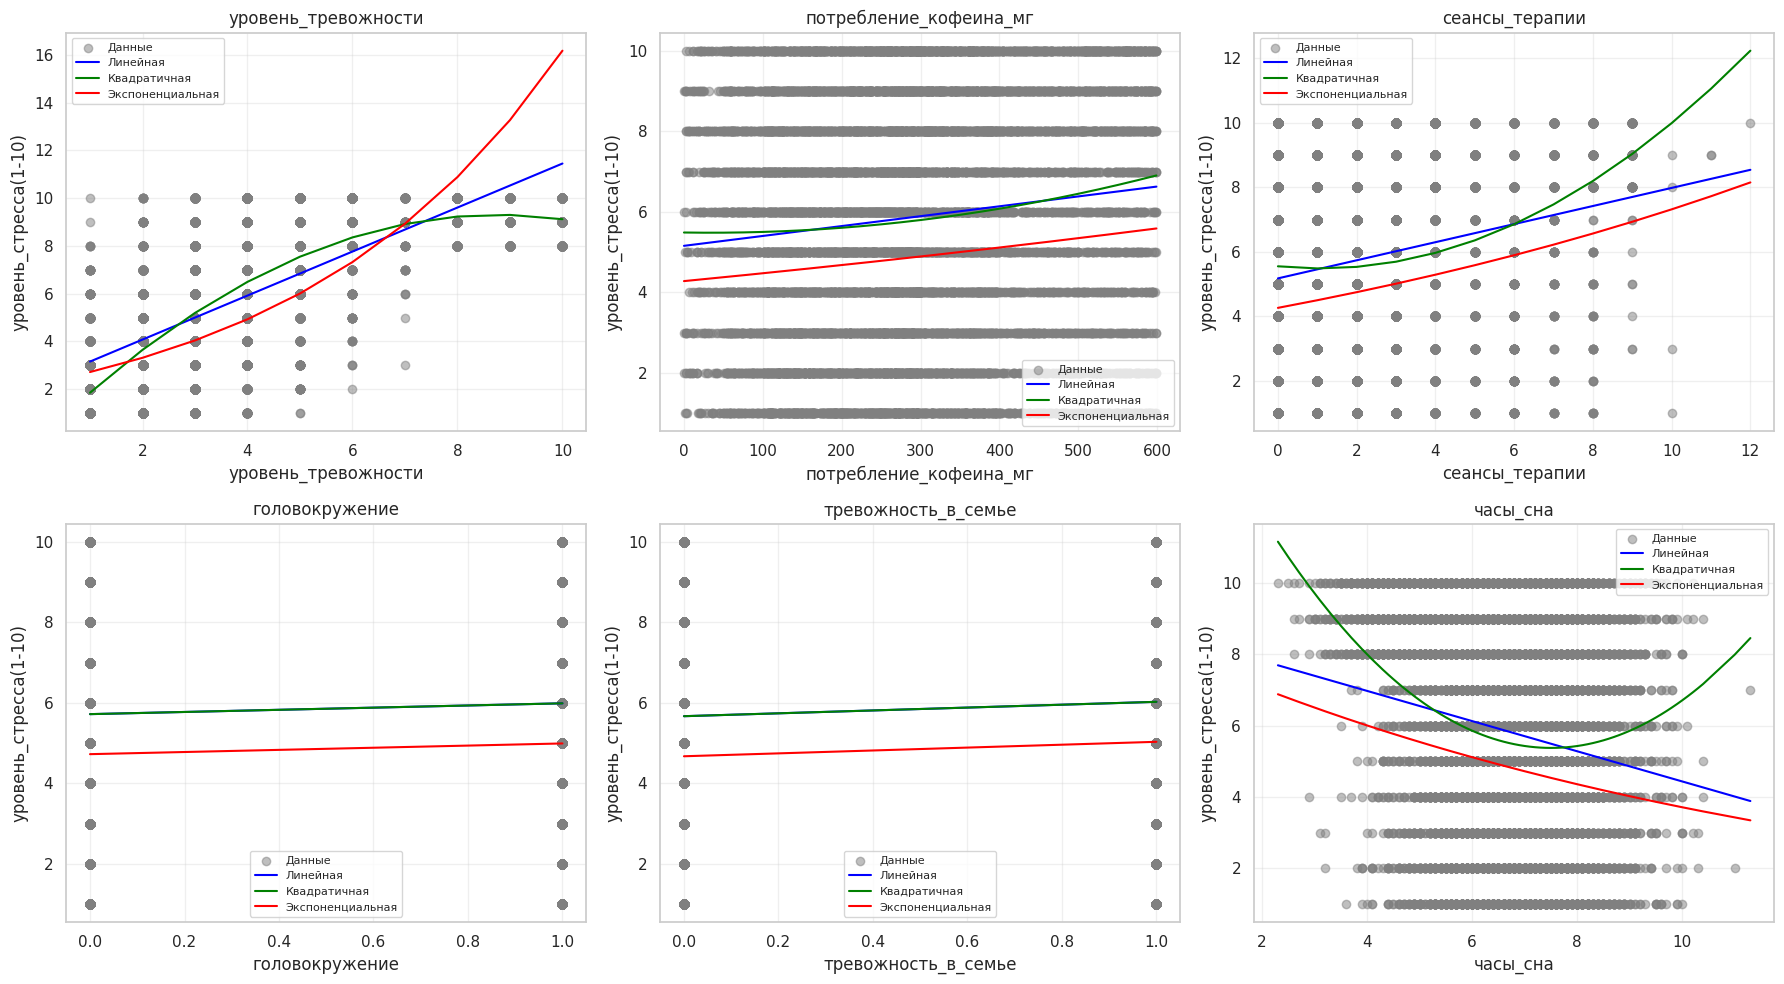


📝 ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ ПО СТАТИСТИЧЕСКОМУ АНАЛИЗУ

1. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ (p-value < 0.05):
   Значимые факторы: уровень_тревожности, потребление_кофеина_мг, сеансы_терапии, головокружение, тревожность_в_семье, часы_сна
   Незначимые: отсутствуют

2. КАЧЕСТВО МОДЕЛЕЙ:
   Множественная регрессия объясняет 51.0% вариации стресса
   MAE = 1.68 (средняя ошибка прогноза)

3. ЛУЧШИЕ МОДЕЛИ ПО ФАКТОРАМ:

Лучшая модель
Квадратичная    4
Линейная        2


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(available_metrics[:6]):
    ax = axes[idx]
    x = df[col].values
    y = df[target].values
    x_sorted = np.sort(x)

    ax.scatter(x, y, alpha=0.5, color='gray', label='Данные')

    # Линейная
    lr = LinearRegression().fit(x.reshape(-1, 1), y)
    ax.plot(x_sorted, lr.predict(x_sorted.reshape(-1, 1)),
            color='blue', label='Линейная')

    # Квадратичная
    poly = PolynomialFeatures(degree=2, include_bias=False)
    x_poly = poly.fit_transform(x_sorted.reshape(-1, 1))
    lr_quad = LinearRegression().fit(poly.fit_transform(x.reshape(-1,1)), y)
    ax.plot(x_sorted, lr_quad.predict(x_poly), color='green', label='Квадратичная')

    # Экспоненциальная
    lr_exp = LinearRegression().fit(x.reshape(-1, 1), np.log(y))
    ax.plot(x_sorted, np.exp(lr_exp.predict(x_sorted.reshape(-1, 1))),
            color='red', label='Экспоненциальная')

    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f'{col}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("📝 ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ ПО СТАТИСТИЧЕСКОМУ АНАЛИЗУ")
print("="*70)
print(f"""
1. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ (p-value < 0.05):
   Значимые факторы: {', '.join(df_stats[df_stats['Значимость']=='Да']['Фактор'].tolist())}
   Незначимые: {', '.join(df_stats[df_stats['Значимость']=='Нет']['Фактор'].tolist()) or 'отсутствуют'}

2. КАЧЕСТВО МОДЕЛЕЙ:
   Множественная регрессия объясняет {r2_score(y_multi, y_pred_multi)*100:.1f}% вариации стресса
   MAE = {mean_absolute_error(y_multi, y_pred_multi):.2f} (средняя ошибка прогноза)

3. ЛУЧШИЕ МОДЕЛИ ПО ФАКТОРАМ:
""")
print(df_comparison['Лучшая модель'].value_counts().to_string())

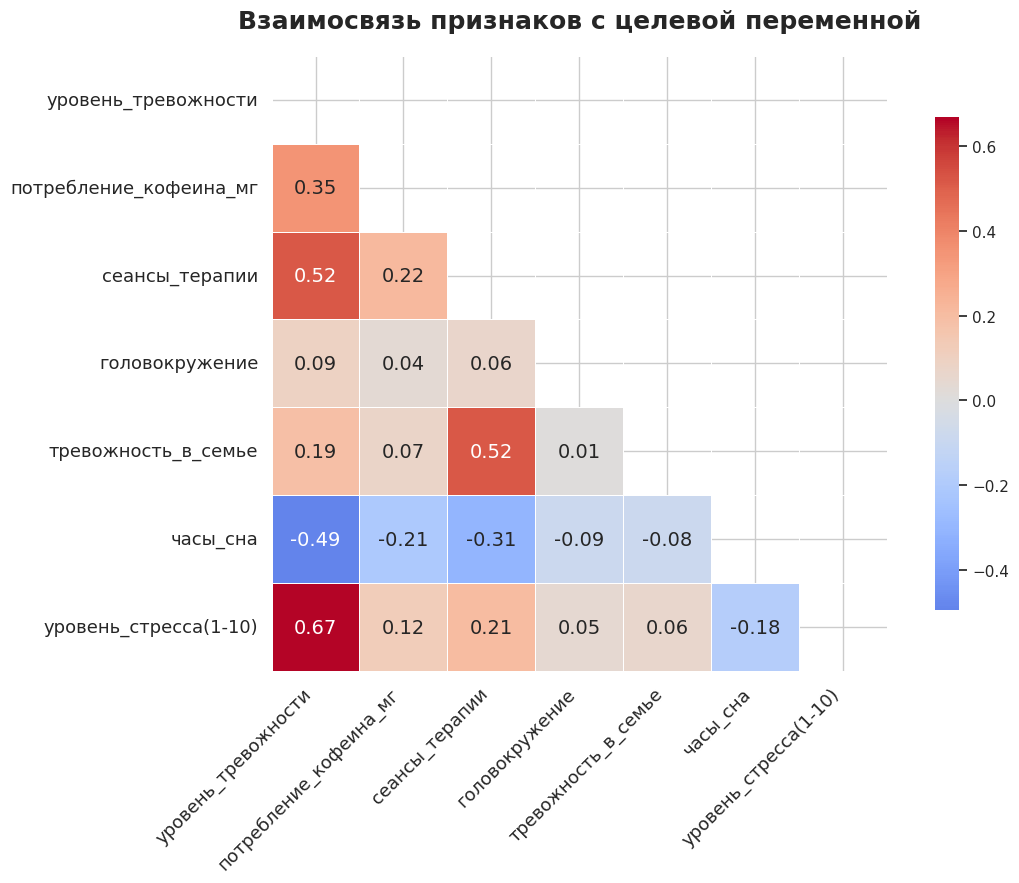

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[available_metrics + [target]].corr()

# 1. Создаем маску для верхнего треугольника (убираем дублирование)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 2. Задаем большой размер (для слайда 16:9 или 4:3 этого будет достаточно)
plt.figure(figsize=(12, 9))

# 3. Настраиваем тепловую карту
sns.heatmap(
    corr,
    mask=mask,               # Скрываем верхний треугольник
    annot=True,              # Показываем цифры
    fmt='.2f',               # Округление до 2 знаков
    cmap='coolwarm',         # или 'RdBu_r' (красно-синий) для строгости
    center=0,                # Ноль — это белый цвет, так проще оценивать силу связи
    square=True,             # Ячейки будут идеально квадратными
    linewidths=0.5,          # Тонкие белые разделители
    cbar_kws={"shrink": 0.8},# Цветовая шкала чуть короче графика
    annot_kws={"size": 14}   # Увеличенный шрифт для цифр внутри ячеек
)

# 4. Крупный заголовок и читаемые оси
plt.title('Взаимосвязь признаков с целевой переменной', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(rotation=0, fontsize=13)

# Убираем лишние рамки (spines), если они мешают
plt.gca().spines[:].set_visible(False)

plt.tight_layout()
plt.show()

## Промежуточный вывод
Промежуточный вывод: интерпретация смены знаков в регрессии
В процессе построения моделей я столкнулся с довольно неочевидным моментом: при переходе от парной регрессии к множественной у некоторых предикторов радикально меняются коэффициенты.
Самый показательный пример — переменная сна.
В парной модели коэффициент отрицательный (β = −0.42), что интуитивно понятно: кажется, что чем больше спишь, тем ниже стресс. Но в множественной модели знак внезапно меняется на положительный (β = +0.44). На первый взгляд, это выглядит как ошибка.
Однако всё встает на свои места, если посмотреть на матрицу корреляций:

    Тревожность ↔ Сон    -0.49

    Тревожность ↔ Стресс  0.67

Здесь мы наблюдаем классический эффект смешивающей переменной. Высокая тревожность в нашей выборке коррелирует как с недосыпом, так и с высоким уровнем стресса. В простой модели переменная «сон» просто забирала на себя эффект тревожности, работая как её прокси. Как только мы добавили уровень тревожности в модель отдельным предиктором, влияние сна «очистилось», и знак изменился.
Если интерпретировать это буквально: при прочих равных (то есть при фиксированном уровне тревожности) люди, которые спят чуть больше среднего по группе, почему-то демонстрируют чуть более высокий стресс. Делать здесь жесткий причинно-следственный вывод, конечно, нельзя — скорее всего, это артефакт выборки или влияние неучтенных факторов (например, люди в остром стрессе пытаются «отоспаться» и проводят в кровати больше времени). Главное, что модель вскрыла эту скрытую структуру данных.
Аналогичная история произошла с переменной «терапия»:

    Парная регрессия: β = +0.28
    Множественная регрессия: β = −0.23

Тут логика еще прозрачнее. Парная модель фактически отражала лишь тот факт, что люди с высоким уровнем стресса чаще обращаются к психотерапевту. А вот множественная модель, контролируя базовую тревожность, показывает уже реальный эффект: при равном уровне тревожности посещение терапии действительно ассоциируется со снижением стресса.

Итог: Эти скачки коэффициентов отлично иллюстрируют, почему так важно не ограничиваться парными зависимостями. Из-за наличия коррелирующих признаков смотреть на простые графики опасно — для адекватных выводов нам обязательно нужно контролировать базовые факторы, что мы и сделали в множественной модели.

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[available_metrics]

vif = pd.DataFrame()
vif["Фактор"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

display(vif.sort_values("VIF", ascending=False))

,Фактор,VIF
0,уровень_тревожности,6.026807
1,потребление_кофеина_мг,5.348240
5,часы_сна,5.066374
2,сеансы_терапии,4.102092
4,тревожность_в_семье,2.953158
3,головокружение,2.040885


In [26]:
X = sm.add_constant(df[available_metrics])
y = df[target]

model = sm.OLS(y, X).fit()

print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     уровень_стресса(1-10)   R-squared:                       0.510
Model:                               OLS   Adj. R-squared:                  0.510
Method:                    Least Squares   F-statistic:                     1908.
Date:                   Fri, 26 Jun 2026   Prob (F-statistic):               0.00
Time:                           05:58:16   Log-Likelihood:                -23497.
No. Observations:                  11000   AIC:                         4.701e+04
Df Residuals:                      10993   BIC:                         4.706e+04
Df Model:                              6                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

## Финальный вывод

Проведенный множественный регрессионный анализ показал, что наиболее значимым фактором, связанным с уровнем стресса, является уровень тревожности (β = 1.22, p < 0.001). Существенное влияние также оказывают количество сеансов терапии, продолжительность сна и потребление кофеина. После учета всех факторов переменные «головокружение» и «тревожность в семье» потеряли статистическую значимость (p > 0.05), что свидетельствует об отсутствии их самостоятельного вклада в объяснение уровня стресса. Построенная модель объясняет около 51% вариации уровня стресса (R² = 0.51), что указывает на хорошую объясняющую способность модели. При этом наблюдается умеренная мультиколлинеарность между отдельными предикторами, прежде всего между тревожностью, сном и посещением терапии, поэтому интерпретация отдельных коэффициентов требует осторожности.